# **Ciencia de Datos en la Toma de Decisiones de las Organizaciones**
### - Exploración de Datos y Análisis Descriptivo
##### Atiende: Iván Barrios y Raúl Castillo


# 1. Importamos librerias necesarias

---



In [ ]:
import pandas as pd
import numpy as np

# 2. Conexión con Google Drive y lectura de datos

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#BBDD - IMDB
### Internet Movie Database (IMDb) es una base de datos en línea que contiene información sobre películas, series de televisión, videojuegos, y más. Es la base de datos de cine y televisión más grande y completa del mundo.

Podemos encontrar:
 - Información sobre actores, directores, y personal técnico
 - Bandas sonoras
 - Resúmenes argumentales
 - Biografías
 - Curiosidades
 - Calificaciones
 - Reseñas
 - Información sobre dónde ver las películas y programas de televisión

BASE EMPLEADA (Metadatos)

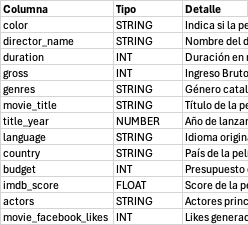


Definición de reglas

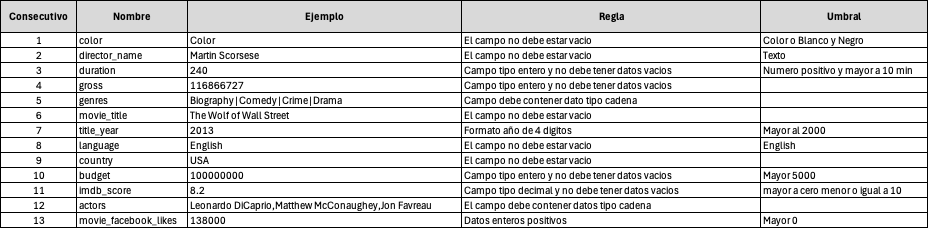

# 3. Exploración Inicial

---

In [ ]:
#leemos el fichero IMDB
imdb=pd.read_csv("/content/drive/MyDrive/IMDB.csv")

Un Primeer vistazo -
 imdb
 .head()
 .tail()
 .saple()

In [ ]:
imdb

In [ ]:
imdb.head(3)
# Por defecto nos mostrará los primeros 5 registros
 # Recuerden, si incluimos un número dentro de "head" o "tail" podemos definir el número de registros que vremos

In [ ]:
imdb.tail(2)
# Por defecto nos mostrará los últimos 5 registros

In [ ]:
imdb.sample(5)
# Información aleatoria
# Debemos definir el número de registros que queremos que nos regrese

- Información General

In [ ]:
imdb.columns
# Nos muestra en una lista las columnas con las que cuanta nuestro DF

In [ ]:
imdb.dtypes
# Nos muestra el esquema de las columnas

In [ ]:
imdb.index
#Nos arroja como resultado el índice de nuestro DF

In [ ]:
imdb.memory_usage(deep=True)
# Arroja como resultado el uso de memoria de cada una de nuestras columnas

 - Estadísticas descriptivas y distribución

In [ ]:
imdb.shape
 # .shape no indica en un atupla, el número de registros por número de columnas que tenemos en nuestra base de datos
 # Podemos ver de forma rápida el tamaño de nuestro DF

In [ ]:
imdb.info()
 # Nos muestra un resumen del DF, incluyendo el número de filas, columnas, nombres de columnas, tipos de datos y valores no nulos
 # Nos ayudará a obtener una visión general de la estructura del DF y detectar valores nulos o tipos de datos incorrectos

In [ ]:
imdb.describe()
# Nos devolverá estadísticas descriptivas para aquellas columnas uqe por defecto son uméricas o para columnas de tipo objeto si se usa describe(include='object').
# Podremmos obtener estadísticas básicas como la media, la desviación estándar, los cuartiles, el valor mínimo y el máximo

In [ ]:
imdb.describe(include='object')
# Nos devolverá estadísticas descriptivas nuestras columnas categóricas

In [ ]:
imdb.describe(include='all')
# Podemos valorar las estadísticas de todas nuestras columnas en un solo paso

In [ ]:
imdb.isnull().sum()
# Detectamos cantidad de registros nulos en nuestras columnas

In [ ]:
imdb.duplicated().sum()
# Nos arroja como resultado la cantidad de registros duplicados en el DF

In [ ]:
imdb[imdb.duplicated()]
# Verificamos cuáles son las filas que tenemos duplicadas

- Análisis de columnas categóricas


In [ ]:
imdb['color'].nunique()
# Nos indicará los valores

In [ ]:
imdb['color'].isnull().sum()

In [ ]:
imdb['color'].unique()
# Nos mostrará una lista con los valores únicos en la columna

In [ ]:
imdb['color'].value_counts()
# Para cada valor único, nos devolverá el conteo de registros

# Data Cleaning

---

## Eliminamos duplicados

In [ ]:
imdb[imdb.duplicated(keep=False)]
# Verificamos la duplicidd en nuestros registros

In [ ]:
imdb2=imdb.copy()
# Generamos una copia de nuestro DF para mantener el original intacto

In [ ]:
imdb2.head(2)

In [ ]:
imdb2.drop_duplicates(inplace=True)
# Eliminamos las filas duplicadas

In [ ]:
imdb2.shape
# Validamos el número de registros actual

In [ ]:
imdb2[imdb2.duplicated(keep=False)]
# Validamos si seguimos teniendo valores duplicados

In [ ]:
imdb2.describe()
# Podemos integrar un .describe() por cada paso para valorar resultados y ver cómo se mueven los estadísticos

## Tratamiento de nulos

Analizamos todos los nulos y decidimos qué hacemos con ellos


In [ ]:
imdb2.isnull().any()
# Recordemos que columnas tienen valores nulos y decidamos qué hacer con ellas

In [ ]:
nulos = imdb2.columns[imdb2.isnull().any()]
print(nulos)
# Extraeos una lista con las columnas que tienen nulos para dar seguimiento

### 1. Variable: **color**

In [ ]:
imdb2["color"].value_counts()

In [ ]:
imdb2["color"] = imdb2["color"].replace("color ", "Color", regex=True)
# Reemplazamos la varibale "color" por "Color" para normalizar

In [ ]:
imdb2["color"].value_counts()

In [ ]:
imdb2["color"] = imdb2["color"].str.strip().str.lower().replace("Color", "Color")
# Es posible que al normalizar, no veamos el resultado deseado y esto se puede dar por espacios dentro de la cadena de texto.
# Pasamos la función .str para eliminar espacios antes y después de la cadena de texto y asegurar el ajuste

In [ ]:
imdb2["color"].value_counts()

Otras opciones:

- imdb2["color"] = imdb2["color"].str.upper()
  - Pasamos todo a mayúsculas
- imdb2["color"] = imdb2["color"].str.lower()
  - Pasamos todo a minúsculas
- imdb2["color"] = imdb2["color"].str.capitalize()
  - Pasamos la primra letra a mayúsculas

Inferimos la categoría por el año de la película
- cruzar con información de año de película para determinar si es Color o B/N

imdb2["color"] = np.where(imdb2["year"] >= 1909, "Color", "black and white")

In [ ]:
imdb2['color'].isnull().sum()
# Verificamos los valores nulos

In [ ]:
del(imdb2["color"])
# Con 11 nulos y el 99% de mis variables en "color", vale la pena quedarnos con la columna?

In [ ]:
imdb2.columns

### 2. Variable: **nombre de director**

In [ ]:
imdb2["director_name"].value_counts()
# Hacemos un conteo para cada valor único

In [ ]:
imdb2[imdb2["director_name"].isnull()]
#Identificamos los registros que no cuentan con un director (Nulos)

In [ ]:
imdb2["director_name"].fillna('sin director', inplace=True)
# Rellenamos los valores nulos con una variable que nosotros definamos

In [ ]:
imdb2[imdb2["director_name"].isnull()]
#Verificamos si seguimos teniendo nulos

### 3. Variable: **ingresos brutos**

In [ ]:
imdb2[imdb2["gross"].isnull()]

In [ ]:
# Un histograma es un gráfico que permite mostrar cómo se distribuyen los datos de una variable numérica.
# En el histograma se suelen usar barras, cuya altura dependerá de la frecuencia de los datos, que corresponde al eje Y.
# En el eje X podemos observar la variable de estudio.

imdb2.hist("gross")

In [ ]:
imdb2[imdb2["gross"]>6e8]

In [ ]:
imdb2["gross"] = imdb2["gross"].fillna(imdb2["gross"].mean())
#imdb2["gross"].fillna(imdb2["gross"].mean(),inplace=True)
# Imputamos los nulos con la media de esta varibale

In [ ]:
imdb2[imdb2["gross"].isnull()]
#VErificamos si aún tenemos nulos

### 4. Variable: **género de la película**


In [ ]:
imdb2["genres"].value_counts()

In [ ]:
imdb2[imdb2["genres"].isnull()]

In [ ]:
imdb2["genres"].fillna("Desconocido", inplace=True)


Eliminamos el nulo

In [ ]:
imdb2.dropna(subset=["genres"], inplace=True)
# Podemos eliminar el registro completo ya que solo es uno

### 5. Variable: **presupuesto**

In [ ]:
imdb2[imdb2["budget"].isnull()]
# Identificamos los registros nulos

In [ ]:
imdb2.hist("budget")
# Generamos histograma pra ver el comportamiento graficado

In [ ]:
imdb2["budget"].fillna(imdb2["budget"].median(),inplace=True)
# Inferimos el valor de los nulos aplicando la media de los valores en Budget

In [ ]:
imdb2.head()
# Revisamos resultados

---

In [ ]:
imdb2.isnull().sum()
# Validamos que ya no tenemos nulos

## **Lógica** de las variables

In [ ]:
imdb3 = imdb2.copy()
# Generamos un nuvo DF para no trabajar sobre el que acabamos de editar

In [ ]:
imdb3.head(2)

In [ ]:
imdb3.hist("duration")
# Generamos un histograma con la duración de las películas con el objetivo de detectar outliers (Valores atípicos)

Observamos la presencia de outliers y vamos a localizarlos

### Tratamiento de outliers

In [ ]:
imdb3[imdb3["duration"]<50]
# Vemos que uno de los princilaes está por debajo de 50

In [ ]:
imdb3[imdb3["duration"]>300]
# el otro está por arriba de 300

Hay varias formas de reemplazarlos

### 1. Funciones *iloc* y *loc* de pandas

iloc[i, j] : Devuelve el elemento que se encuentra en la fila i y la columna j del DataFrame

In [ ]:
imdb3.iloc[6,:]
# Para este ejmplo queremos ver todos los elementos de la fila 6 (index), por lo que solo ponemos el 6 y ":"

loc[] es un método para seleccionar y filtrar datos en un DataFrame de Pandas. El método loc[] toma uno o dos argumentos, que pueden ser una etiqueta de fila o una matriz booleana.

In [ ]:
imdb3.loc[(imdb3["duration"]<50) |(imdb3["duration"]>300),'duration'] = imdb3["duration"].mean()
# Utilizamos loc[] para acceder a las filas de imdb3 donde la columna "duration" cumple alguna de estas dos condiciones:
 # El valor de "duration" es menor que 50 (imdb3["duration"] < 50).
 # El valor de "duration" es mayor que 300 (imdb3["duration"] > 300).
 # El operador "|" representa una "o" lógica (OR).
# Si las condiciones se cumple, aplica el promedio de duración en los valores atípicos

In [ ]:
imdb3.hist("duration")

### 2. Función *np.where* de numpy

In [ ]:
imdb3 = imdb2.copy()

In [ ]:
imdb3['duration']= np.where(imdb3['duration']<=50,imdb3["duration"].mean(),imdb3['duration'])
# Usamos condiciones lógicas para poder ajustar el valor en "duration"
 # Si se cumple la condición, aplicamos el valos promedio

In [ ]:
imdb3['duration']= np.where(imdb3['duration']>300,imdb3["duration"].mean(),imdb3['duration'])

In [ ]:
imdb3.hist("duration")

### 3. Función *drop* de pandas

In [ ]:
imdb3 = imdb2.copy()

In [ ]:
imdb3[(imdb3["duration"]<50) |(imdb3["duration"]>300)].index
# Identificamos la fila donde se localizan los valores atípicos con respecto al índice

In [ ]:
len(imdb3)
# VAlidamos el número de registros actuales

In [ ]:
imdb3.drop(imdb3[(imdb3["duration"]<50) |(imdb3["duration"]>300)].index, inplace=True)
# Elominamos los registros con respecto a su localización en el índice por medio de la condición lógica

In [ ]:
len(imdb3)
# Validamos que hemos elliinado los registros

### Tratamiento de la variable género

Recordemos que en género tenemos los diversos géneros asignados a la película separados por una barra.

In [ ]:
genero_list=imdb3["genres"].str.split("|", expand=True)
# Accedemos a la columna "genres" del DF imdb3.
# Dividimos el contenido de cada fila de esa columna utilizando el carácter "|" como delimitador y generamos un nuevo DF

In [ ]:
genero_list

In [ ]:
genero_list.fillna('sin genero', inplace=True)
# Buscamos valores nulos (NaN) en el DF genero_list.
 # Reemplazamos esos valores nulos con la cadena 'sin genero'.

In [ ]:
for i in genero_list:
  imdb3["genero_"+str(i)]=genero_list[i]

# Iteramos sobre cada columna en el DF genero_list usando un bucle for.
  # "i" toma el nombre de cada columna en genero_list.
    # Crea nuevas columnas en el DF imdb3 con nombres dinámicos usando el prefijo "genero_" seguido del nombre de la columna actual (i).

In [ ]:
imdb3

In [ ]:
del(imdb3["genres"])
# Podemos eliminar la columna orifinal de "genres"

Como siguientes pasos analizar las variables restantes:
- language
- country
- actors (separarlo)*texto en cursiva*
- imdb_score
- movie_facebook_likes

Además, si se observan:
- Datos que son outliers deberán limpiarlos!
- Columnas con poca utilidad podrán borrarlas!